# EDA — UCDP GEDEvent 25.1, Russia-Ukraine Subset
**Project:** Conversational Clustering  
**Version:** v0.1  

This notebook performs exploratory data analysis on the UCDP Georeferenced Event Dataset (GED) v25.1, filtered to events in Ukraine from 2022-02-24 onward. It also draws and saves the experimental sample used in all subsequent runs.

**Prerequisites:** Download `GEDEvent_v25_1.csv` from https://ucdp.uu.se/downloads/ and place it at `data/raw/GEDEvent_v25_1.csv`.

---


## 0. Imports and Configuration

In [3]:
import os, sys, hashlib, warnings, textwrap
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline

# ── Paths ────────────────────────────────────────────────────────────────
RAW_PATH   = Path("../data/raw/GEDEvent_v25_1.csv")
OUT_DIR    = Path("../data/eda_outputs")
SAMPLE_OUT = Path("../data/sample_seed42.csv")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.15)
COLORS = sns.color_palette("muted", 10)
plt.rcParams["figure.dpi"] = 120

# ── Helper: MD5 hash ─────────────────────────────────────────────────────
def md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

print("Environment ready.")


Environment ready.


## 1. Load Raw Data and Compute Provenance Hash

The MD5 hash is recorded here and in `docs/data_provenance.md §1.1` to guarantee reproducibility: any reviewer with the same raw file will produce the same hash.


In [4]:
if not RAW_PATH.exists():
    sys.exit(
        f"\n[ERROR] Raw data not found at {RAW_PATH}.\n"
        "Download GEDEvent 25.1 CSV from https://ucdp.uu.se/downloads/\n"
        "and place it at data/raw/GEDEvent_v25_1.csv\n"
    )

raw_hash = md5(RAW_PATH)
raw = pd.read_csv(RAW_PATH, low_memory=False)

print(f"File path  : {RAW_PATH}")
print(f"MD5        : {raw_hash}  ← record this in docs/data_provenance.md §1.1")
print(f"Shape      : {raw.shape[0]:,} rows × {raw.shape[1]} columns")
print(f"Columns    : {list(raw.columns)}")

File path  : ../data/raw/GEDEvent_v25_1.csv
MD5        : 56d33581a615c8e3772b7500c8a2c1c6  ← record this in docs/data_provenance.md §1.1
Shape      : 385,918 rows × 49 columns
Columns    : ['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence', 'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id', 'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a', 'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources', 'source_article', 'source_office', 'source_date', 'source_headline', 'source_original', 'where_prec', 'where_coordinates', 'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude', 'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region', 'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low', 'gwnoa', 'gwnob']


## 2. Filter to Russia-Ukraine Conflict (post 2022-02-24)

**Filter criteria (from `docs/study_design.md §2.3`):**
- `country_id == 369` — Ukraine (Gleditsch-Ward code)  
- `date_start >= 2022-02-24` — full-scale invasion start date

Events on Russian soil are excluded; GED coverage there is sparse and follows a different reporting regime.


In [5]:
raw["date_start"] = pd.to_datetime(raw["date_start"], errors="coerce")
INVASION_DATE  = pd.Timestamp("2022-02-24")
UA_COUNTRY_ID  = 369

# Count all Ukraine events across all years (needed for data_provenance.md §5.1)
ua_all_years = (raw["country_id"] == UA_COUNTRY_ID).sum()
print(f"All Ukraine events (1989-2024)  : {ua_all_years:,}")

mask = (raw["country_id"] == UA_COUNTRY_ID) & (raw["date_start"] >= INVASION_DATE)
df_full = raw[mask].copy()

# Keep only the columns relevant to this study
FEATURE_COLS = [
    "id", "date_start", "type_of_violence",
    "conflict_name", "dyad_name",
    "side_a", "side_b",
    "country", "adm_1", "adm_2",
    "latitude", "longitude", "geo_precision",
    "best", "low", "high",
    "deaths_civilians", "deaths_a", "deaths_b", "deaths_unknown",
    "where_description", "active_year",
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_full.columns]
df = df_full[FEATURE_COLS].copy()

russia_side_a = df["side_a"].str.contains("Russia", case=False, na=False).sum()

print(f"Events in Ukraine ≥ 2022-02-24 : {len(df):,}")
print(f"  of which side_a mentions Russia: {russia_side_a:,}")
print(f"  Date range: {df['date_start'].min().date()} – {df['date_start'].max().date()}")
print(f"  Columns retained: {df.shape[1]}")


All Ukraine events (1989-2024)  : 31,547
Events in Ukraine ≥ 2022-02-24 : 27,942
  of which side_a mentions Russia: 27,942
  Date range: 2022-02-24 – 2024-12-31
  Columns retained: 21


## 3. Data Quality Assessment

We check for nulls, duplicates, and the geo-precision distribution — the three most consequential quality issues for clustering.


In [9]:
print(f"Subset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Duplicate event IDs: {df['id'].duplicated().sum()}")

null_df = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_%":     (df.isnull().mean() * 100).round(1),
}).query("null_count > 0").sort_values("null_%", ascending=False)

display(null_df.style.background_gradient(subset=["null_%"], cmap="YlOrRd"))


Subset shape: 27,942 rows × 21 columns
Duplicate event IDs: 0


,null_count,null_%
adm_2,5535,19.800000
adm_1,1910,6.800000
where_description,803,2.900000


### 3.1 Clustering Feature Readiness

For each feature that enters the clustering pipeline, we report null rate and cardinality.  
High cardinality in categorical fields drives one-hot dimensionality; very low null rates confirm these fields are usable without imputation.


In [10]:
CLUSTER_FEATURES = {
    "type_of_violence": "categorical (1/2/3)",
    "side_a":           "categorical (actor name)",
    "side_b":           "categorical (actor name)",
    "adm_1":            "categorical (oblast)",
    "adm_2":            "categorical (raion)",
    "latitude":         "continuous",
    "longitude":        "continuous",
    "best":             "continuous (fatality estimate)",
}

rows = []
for feat, ftype in CLUSTER_FEATURES.items():
    present = feat in df.columns
    rows.append({
        "Feature":      feat,
        "Type":         ftype,
        "Present":      "✓" if present else "✗ MISSING",
        "Null %":       f"{df[feat].isnull().mean()*100:.1f}%" if present else "—",
        "Cardinality":  f"{df[feat].nunique():,}"              if present else "—",
    })

display(pd.DataFrame(rows).set_index("Feature"))


,Type,Present,Null %,Cardinality
Feature,,,,
type_of_violence,categorical (1/2/3),✓,0.0%,2
side_a,categorical (actor name),✓,0.0%,1
side_b,categorical (actor name),✓,0.0%,2
adm_1,categorical (oblast),✓,6.8%,26
adm_2,categorical (raion),✓,19.8%,128
latitude,continuous,✓,0.0%,"2,031"
longitude,continuous,✓,0.0%,"2,031"
best,continuous (fatality estimate),✓,0.0%,230


## 4. Event Type Distribution (`type_of_violence`)

Three UCDP violence categories:
- **1 — State-based conflict:** organized armed actor vs. another organized actor, at least one side is a government.
- **2 — Non-state conflict:** between non-governmental organized groups.
- **3 — One-sided violence:** organized actor vs. civilians.

The distribution informs whether `type_of_violence` will be a discriminating feature in clustering.


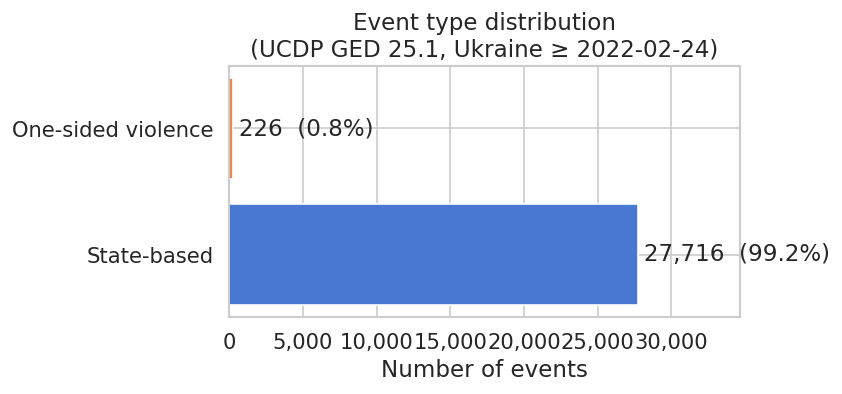

type_of_violence
State-based           27716
One-sided violence      226


In [11]:
tov_labels = {1: "State-based", 2: "Non-state", 3: "One-sided violence"}
tov_counts = df["type_of_violence"].map(tov_labels).value_counts()

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(tov_counts.index, tov_counts.values, color=COLORS[:3])
ax.bar_label(bars, labels=[f"{v:,}  ({v/len(df)*100:.1f}%)" for v in tov_counts.values], padding=4)
ax.set_xlabel("Number of events")
ax.set_title("Event type distribution\n(UCDP GED 25.1, Ukraine ≥ 2022-02-24)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xlim(0, tov_counts.max() * 1.25)
plt.tight_layout()
fig.savefig(OUT_DIR / "01_event_type_distribution.png", dpi=150)
plt.show()

print(tov_counts.to_string())


## 5. Fatality Distribution (`best` estimate)

UCDP provides three fatality estimates per event (`low`, `best`, `high`). We use `best` throughout.  
The distribution is expected to be **heavily right-skewed** — most events record 1–10 deaths; a small number of major engagements record hundreds. We apply `log(1 + best)` for clustering.

**Key question:** How many events have `best = 0`? These are events where only `low` or `high` estimates exist; they should be checked.


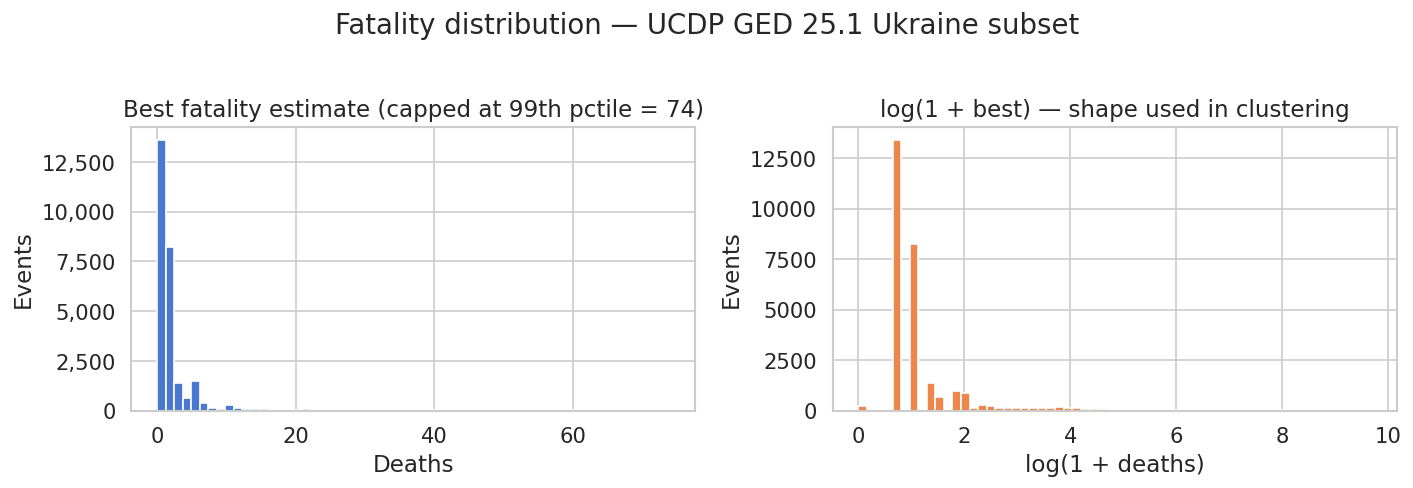

count    27942.00
mean         8.45
std        142.05
min          0.00
25%          1.00
50%          2.00
75%          2.00
max      15996.00

Events with best == 0 : 206  (0.7%)
Events with best >= 100: 166
99th percentile        : 74


In [12]:
fat = df["best"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw (capped at 99th pctile for visibility)
cap = fat.quantile(0.99)
axes[0].hist(fat[fat <= cap], bins=60, color=COLORS[0], edgecolor="white")
axes[0].set_title(f"Best fatality estimate (capped at 99th pctile = {cap:.0f})")
axes[0].set_xlabel("Deaths")
axes[0].set_ylabel("Events")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

# Log-transformed
log_fat = np.log1p(fat)
axes[1].hist(log_fat, bins=60, color=COLORS[1], edgecolor="white")
axes[1].set_title("log(1 + best) — shape used in clustering")
axes[1].set_xlabel("log(1 + deaths)")
axes[1].set_ylabel("Events")

plt.suptitle("Fatality distribution — UCDP GED 25.1 Ukraine subset", y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / "02_fatality_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(fat.describe().round(2).to_string())
print(f"\nEvents with best == 0 : {(fat==0).sum():,}  ({(fat==0).mean()*100:.1f}%)")
print(f"Events with best >= 100: {(fat>=100).sum():,}")
print(f"99th percentile        : {cap:.0f}")


## 6. Temporal Distribution

Monthly event counts reveal temporal clustering of violence — offensive surges, seasonal patterns, and data-coverage gaps toward the end of the reporting period (second-pass coding lag).


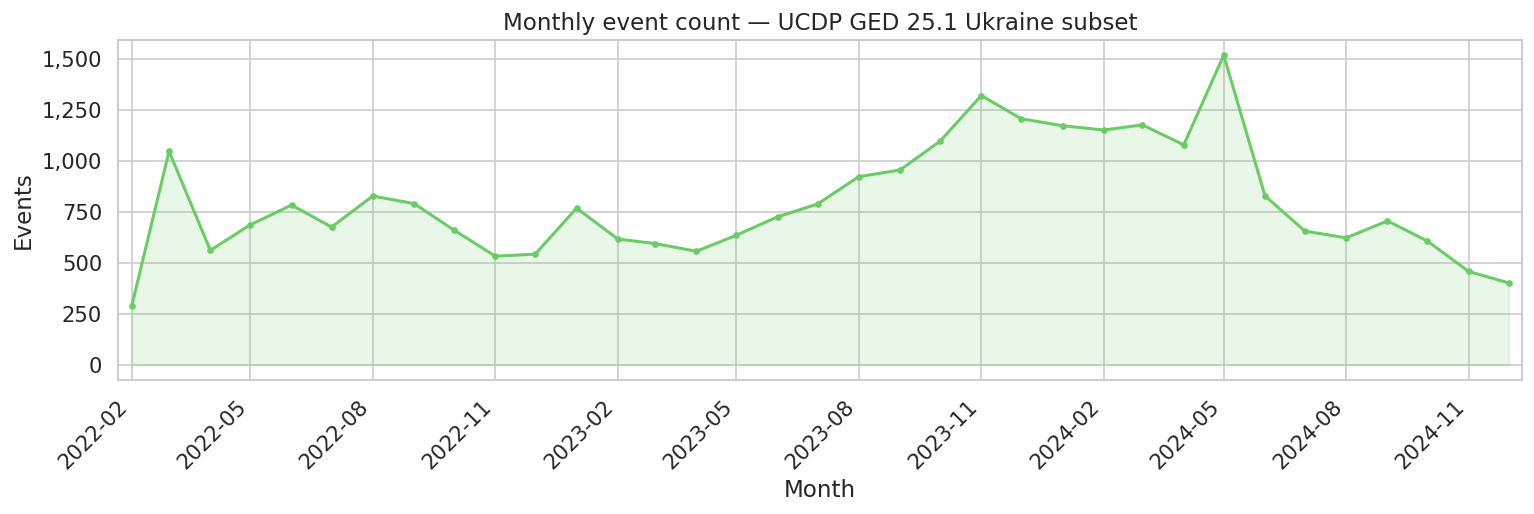

Peak months (top 5):
month
2024-05-01    1518
2023-11-01    1320
2023-12-01    1206
2024-03-01    1176
2024-01-01    1172

Lowest recent months (possible coding lag — last 3):
month
2024-10-01    606
2024-11-01    457
2024-12-01    401


In [13]:
monthly = (
    df.assign(month=df["date_start"].dt.to_period("M").dt.to_timestamp())
      .groupby("month")
      .size()
      .sort_index()
)

fig, ax = plt.subplots(figsize=(13, 4.5))

ax.plot(
    monthly.index,
    monthly.values,
    marker="o",
    markersize=3,
    linewidth=1.8,
    color=COLORS[2],
)

ax.fill_between(
    monthly.index,
    monthly.values,
    0,
    alpha=0.15,
    color=COLORS[2],
)

# Make the x-axis readable: one tick every 3 months.
ax.set_xticks(monthly.index[::3])
ax.set_xticklabels(
    [d.strftime("%Y-%m") for d in monthly.index[::3]],
    rotation=45,
    ha="right"
)

ax.set_xlabel("Month")
ax.set_ylabel("Events")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.set_title("Monthly event count — UCDP GED 25.1 Ukraine subset")
ax.margins(x=0.01)

plt.tight_layout()
fig.savefig(OUT_DIR / "03_temporal_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Peak months (top 5):")
print(monthly.nlargest(5).to_string())

print("\nLowest recent months (possible coding lag — last 3):")
print(monthly.tail(3).to_string())

## 7. Geographic Distribution

Hexbin density map of event coordinates. Concentration along the eastern front (Donetsk, Zaporizhzhia, Kherson oblasts) is expected. Events concentrated at a single point may indicate precision-3/4 geocoding (oblast or country centroid).


Events with valid coordinates: 27,942 / 27,942  (100.0%)


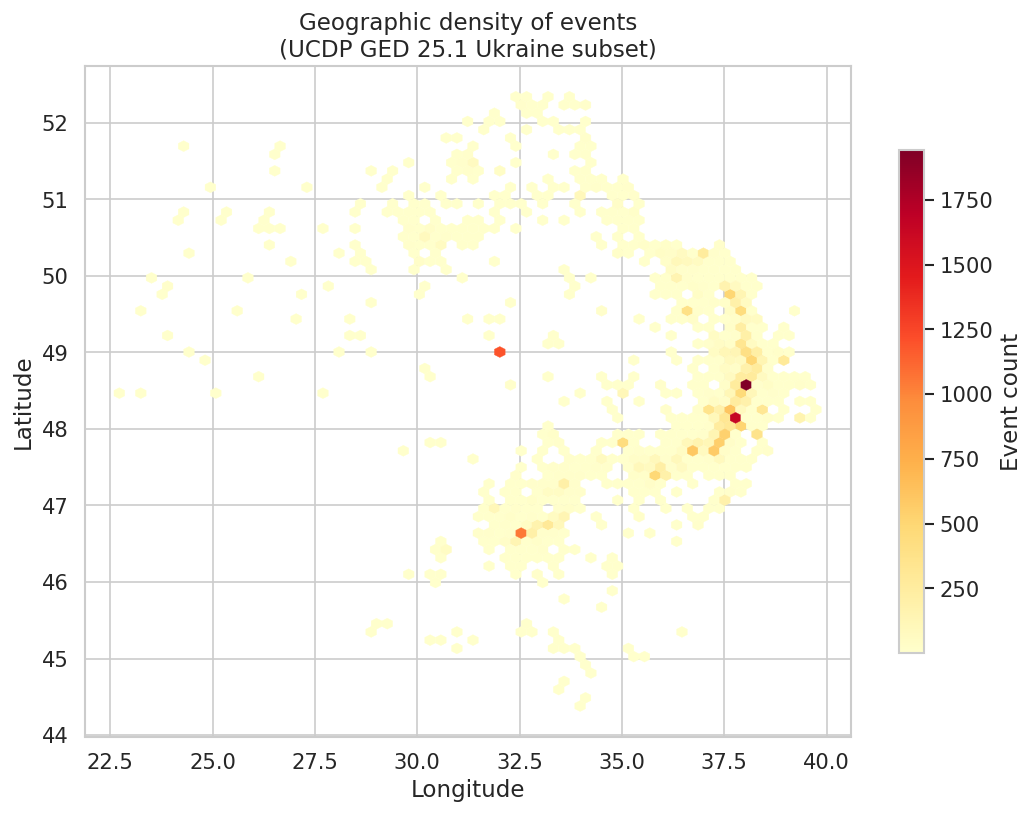

In [14]:
valid_geo = df[["latitude", "longitude"]].dropna()
print(f"Events with valid coordinates: {len(valid_geo):,} / {len(df):,}  ({len(valid_geo)/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 7))
h = ax.hexbin(
    valid_geo["longitude"], valid_geo["latitude"],
    gridsize=65, cmap="YlOrRd", mincnt=1, linewidths=0.2
)
cb = fig.colorbar(h, ax=ax, shrink=0.75)
cb.set_label("Event count")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geographic density of events\n(UCDP GED 25.1 Ukraine subset)")
plt.tight_layout()
fig.savefig(OUT_DIR / "04_geographic_heatmap.png", dpi=150)
plt.show()


## 8. Geographic Precision Distribution

UCDP assigns a geo-precision code to each event:
- **1 — Village / town** (best): coordinates from a named settlement.
- **2 — ADM2 (raion):** coordinates from the district centroid.
- **3 — ADM1 (oblast):** coordinates from the oblast centroid.
- **4 — Country centroid** (worst): used when location is unknown within the country.

**Implication for clustering:** Events at precision 3–4 are artificially concentrated at a few administrative centroids, creating spurious geographic density. A high proportion of precision-1 events means geographic features are trustworthy.


In [15]:
if "geo_precision" in df.columns:
    gp_labels = {1: "1 – Village/town", 2: "2 – ADM2 (raion)",
                 3: "3 – ADM1 (oblast)", 4: "4 – Country centroid"}
    # Store raw counts keyed by precision code for the summary writer
    gp_raw_counts = df["geo_precision"].value_counts().sort_index()
    gp_counts = df["geo_precision"].map(gp_labels).value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(7, 3.5))
    bars = ax.bar(gp_counts.index, gp_counts.values, color=COLORS[5], edgecolor="white")
    ax.bar_label(bars, labels=[f"{v:,}\n({v/len(df)*100:.1f}%)" for v in gp_counts.values], padding=3)
    ax.set_ylabel("Events")
    ax.set_ylim(0, gp_counts.max() * 1.2)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.set_title("Geographic precision level\n(UCDP GED 25.1 Ukraine subset)")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "07_geo_precision_distribution.png", dpi=150)
    plt.show()

    pct_precise = (df["geo_precision"] <= 2).mean() * 100
    print(f"Events at precision 1 or 2: {pct_precise:.1f}%  ← geographic features are reliable for this share")
    print(f"Events at precision 3 or 4: {100-pct_precise:.1f}%  ← these will cluster at oblast/country centroids")


## 9. Actor Landscape

The cardinality of `side_a` and `side_b` determines the dimensionality of one-hot encoded actor features. Very high cardinality (many unique actors) may require truncation to the top-N actors by frequency.


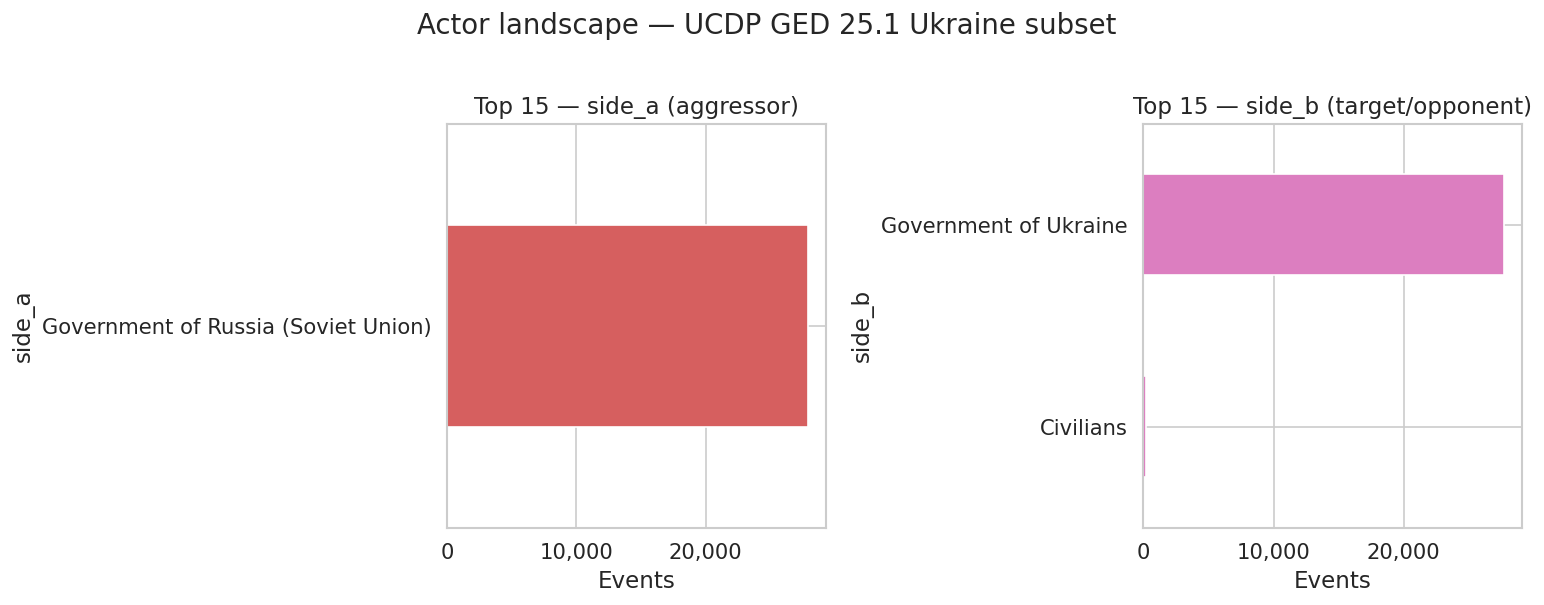

Unique side_a actors : 1
Unique side_b actors : 2

Top 10 side_a:
side_a
Government of Russia (Soviet Union)    27942

Top 10 side_b:
side_b
Government of Ukraine    27716
Civilians                  226


In [16]:
top_a = df["side_a"].value_counts().head(15)
top_b = df["side_b"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, counts, label, color in zip(
    axes, [top_a, top_b], ["side_a (aggressor)", "side_b (target/opponent)"], [COLORS[3], COLORS[6]]
):
    counts[::-1].plot(kind="barh", ax=ax, color=color)
    ax.set_xlabel("Events")
    ax.set_title(f"Top 15 — {label}")
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

plt.suptitle("Actor landscape — UCDP GED 25.1 Ukraine subset", y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / "05_top_actors.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Unique side_a actors : {df['side_a'].nunique():,}")
print(f"Unique side_b actors : {df['side_b'].nunique():,}")
print(f"\nTop 10 side_a:\n{top_a.head(10).to_string()}")
print(f"\nTop 10 side_b:\n{top_b.head(10).to_string()}")


## 10. Event Distribution by Oblast (`adm_1`)

Expected pattern: Donetsk, Zaporizhzhia, Kherson, Kharkiv, and Luhansk oblasts dominate — reflecting the geographic concentration of frontline fighting in eastern and southern Ukraine.


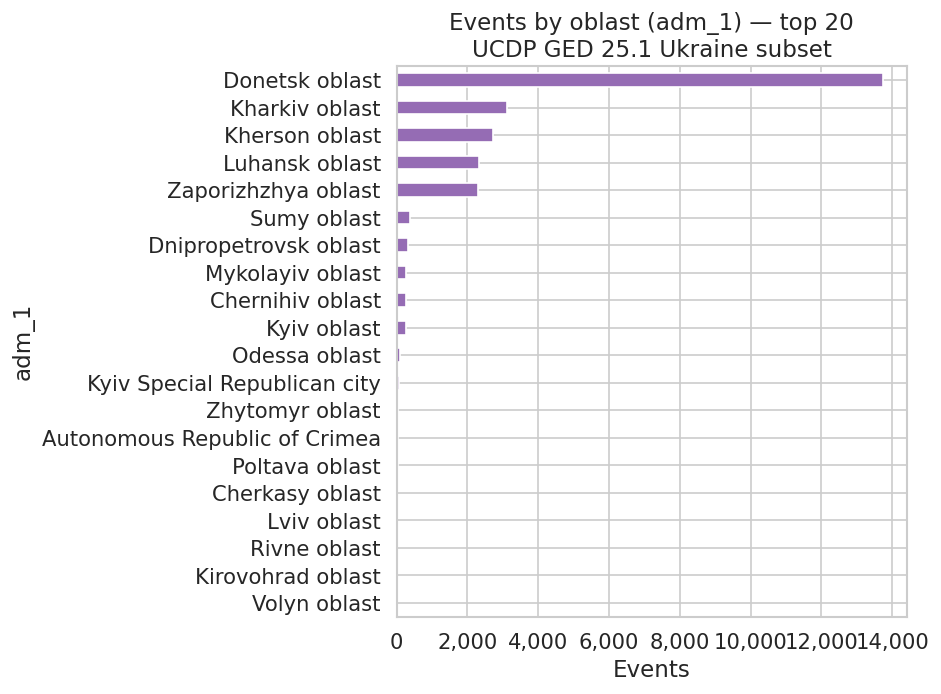

adm_1
Donetsk oblast                   13731
Kharkiv oblast                    3125
Kherson oblast                    2731
Luhansk oblast                    2327
Zaporizhzhya oblast               2295
Sumy oblast                        366
Dnipropetrovsk oblast              325
Mykolayiv oblast                   270
Chernihiv oblast                   261
Kyiv oblast                        255
Odessa oblast                       83
Kyiv Special Republican city        58
Zhytomyr oblast                     36
Autonomous Republic of Crimea       28
Poltava oblast                      26
Cherkasy oblast                     18
Lviv oblast                         18
Rivne oblast                        14
Kirovohrad oblast                   13
Volyn oblast                        11

Top 3 oblasts account for 70.1% of all events — geographic concentration note.


In [17]:
if "adm_1" in df.columns:
    top_adm1 = df["adm_1"].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(8, 6))
    top_adm1[::-1].plot(kind="barh", ax=ax, color=COLORS[4], edgecolor="white")
    ax.set_xlabel("Events")
    ax.set_title("Events by oblast (adm_1) — top 20\nUCDP GED 25.1 Ukraine subset")
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    plt.tight_layout()
    fig.savefig(OUT_DIR / "06_adm1_distribution.png", dpi=150)
    plt.show()

    print(top_adm1.to_string())
    top3_share = top_adm1.head(3).sum() / len(df) * 100
    print(f"\nTop 3 oblasts account for {top3_share:.1f}% of all events — geographic concentration note.")
else:
    top_adm1 = None


## 11. `where_description` Text Field Quality

This field contains the raw location description from the source text. It is a candidate for sentence embedding (open question in `docs/study_plan.md §7`). We assess:
- What fraction of events have a non-null, non-empty description?
- How long are the descriptions? Very short entries (< 10 chars) add little over the structured geographic fields.


Non-null entries  : 27,139 / 27,942  (97.1%)
Empty strings     : 0
Median length     : 32 chars
Mean length       : 46.3 chars
Entries < 10 chars: 2,821  (10.4%)


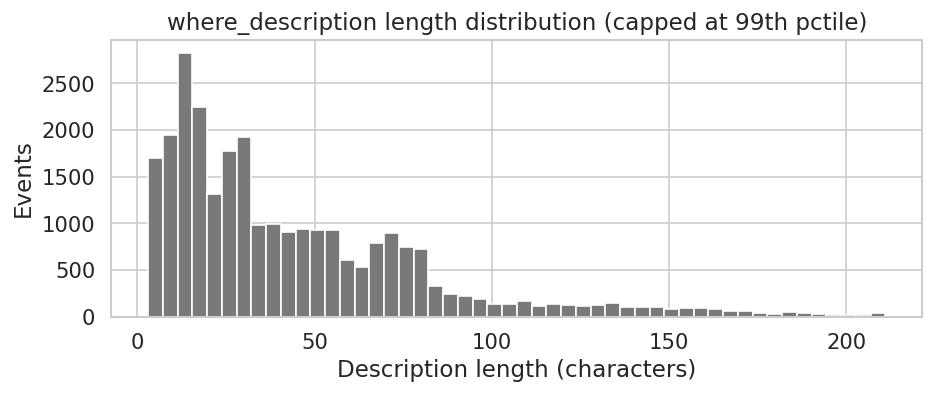


Sample entries:
  • Kherson direction
  • Kostyantynivka in Donetsk region
  • Donetsk region: Avdiivka and Chasovoy Yar
  • Bilohorivka
  • Pisky

── §5.8 Null rates for clustering features ──
  adm_1       : 1,910 nulls  (6.84%)
  adm_2       : 5,535 nulls  (19.81%)
  latitude    : 0 nulls  (0.00%)
  longitude   : 0 nulls  (0.00%)
  best        : 0 nulls  (0.00%)

── §5.8 Comma-separated actor name check ──
  side_a: 0 entries contain a comma  (0.0%)
  side_b: 0 entries contain a comma  (0.0%)


In [18]:
if "where_description" in df.columns:
    wd = df["where_description"].dropna()
    wd_len = wd.str.strip().str.len()
    empty = (wd.str.strip() == "").sum()

    print(f"Non-null entries  : {len(wd):,} / {len(df):,}  ({len(wd)/len(df)*100:.1f}%)")
    print(f"Empty strings     : {empty}")
    print(f"Median length     : {wd_len.median():.0f} chars")
    print(f"Mean length       : {wd_len.mean():.1f} chars")
    print(f"Entries < 10 chars: {(wd_len < 10).sum():,}  ({(wd_len < 10).mean()*100:.1f}%)")

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(wd_len[wd_len <= wd_len.quantile(0.99)], bins=50, color=COLORS[7], edgecolor="white")
    ax.set_xlabel("Description length (characters)")
    ax.set_ylabel("Events")
    ax.set_title("where_description length distribution (capped at 99th pctile)")
    plt.tight_layout()
    plt.show()

    print("\nSample entries:")
    for v in wd.dropna().sample(5, random_state=42).values:
        print(f"  • {textwrap.shorten(str(v), 100)}")

# ── §5.8 quality checklist: null rates for clustering features ────────────
print("\n── §5.8 Null rates for clustering features ──")
for feat in ["adm_1", "adm_2", "latitude", "longitude", "best"]:
    if feat in df.columns:
        n = df[feat].isnull().sum()
        print(f"  {feat:<12}: {n:,} nulls  ({n/len(df)*100:.2f}%)")

# ── §5.8 quality checklist: comma-separated actor names ──────────────────
print("\n── §5.8 Comma-separated actor name check ──")
for col in ["side_a", "side_b"]:
    if col in df.columns:
        n_multi = df[col].str.contains(",", na=False).sum()
        pct = n_multi / len(df) * 100
        print(f"  {col}: {n_multi:,} entries contain a comma  ({pct:.1f}%)")
        if n_multi > 0:
            print("  Examples:")
            examples = df.loc[df[col].str.contains(",", na=False), col].unique()[:3]
            for ex in examples:
                print(f"    • {ex}")


## 12. Draw and Save Experimental Sample

**This cell is the authoritative sample-generation step.**

- N = 2,000 events, `random_state = 42` (fixed in `docs/study_design.md §2.3`).
- The output file `data/sample_seed42.csv` is committed to the repository.
- Its MD5 hash is recorded in `docs/data_provenance.md §1.1`.
- **Do not re-run this cell after committing the sample file** — doing so without a protocol amendment violates the pre-registration.


In [19]:
N_SAMPLE = 2000
SEED     = 42

if len(df) < N_SAMPLE:
    print(f"[WARN] Filtered subset has only {len(df):,} events — using all (no downsampling).")
    sample = df.copy()
else:
    sample = df.sample(n=N_SAMPLE, random_state=SEED)
    print(f"Sampled {N_SAMPLE:,} from {len(df):,} events using seed {SEED}.")

sample.to_csv(SAMPLE_OUT, index=False)
sample_hash = md5(SAMPLE_OUT)

print(f"\nSample saved to    : {SAMPLE_OUT}")
print(f"Sample MD5         : {sample_hash}  ← record this in docs/data_provenance.md §1.1")
print(f"Date range (sample): {sample['date_start'].min().date()} – {sample['date_start'].max().date()}")
print(f"\nSample type_of_violence distribution:")
print(sample["type_of_violence"].map(tov_labels).value_counts().to_string())


Sampled 2,000 from 27,942 events using seed 42.

Sample saved to    : ../data/sample_seed42.csv
Sample MD5         : 97a7b1673e78d26834d6237d1c6cbe39  ← record this in docs/data_provenance.md §1.1
Date range (sample): 2022-02-24 – 2024-12-31

Sample type_of_violence distribution:
type_of_violence
State-based           1989
One-sided violence      11


## 13. Write EDA Summary Text

Writes `data/eda_outputs/eda_summary.txt` — a machine-readable plain-text summary for pasting into `docs/data_provenance.md §5`.


In [20]:
fat_nonnull = df["best"].dropna()
summary_path = OUT_DIR / "eda_summary.txt"

lines = [
    "UCDP GED 25.1 - Ukraine Subset EDA Summary",
    "=" * 52,
    f"Raw file MD5          : {raw_hash}",
    f"Raw file rows         : {raw.shape[0]:,}",
    f"Raw file columns      : {raw.shape[1]}",
    "",
    "-- Filter ------------------------------------------------",
    "  country_id == 369 AND date_start >= 2022-02-24",
    f"  Filtered rows         : {len(df):,}",
    f"  Date range            : {df['date_start'].min().date()} - {df['date_start'].max().date()}",
    f"  Duplicate IDs         : {df['id'].duplicated().sum()}",
    "",
    "-- Type of violence --------------------------------------",
]

for k, v in df["type_of_violence"].map(tov_labels).value_counts().items():
    lines.append(f"  {k:<25}: {v:>6,}  ({v/len(df)*100:.1f}%)")

lines += [
    "",
    "-- Fatality estimate (best) ------------------------------",
    f"  Min                   : {fat_nonnull.min():.0f}",
    f"  Median                : {fat_nonnull.median():.1f}",
    f"  Mean                  : {fat_nonnull.mean():.1f}",
    f"  99th pctile           : {fat_nonnull.quantile(0.99):.0f}",
    f"  Max                   : {fat_nonnull.max():.0f}",
    f"  best == 0             : {(fat_nonnull==0).sum():,}  ({(fat_nonnull==0).mean()*100:.1f}%)",
    "",
    "-- Experimental sample -----------------------------------",
    f"  N                     : {len(sample):,}",
    f"  Seed                  : {SEED}",
    f"  Path                  : {SAMPLE_OUT}",
    f"  MD5                   : {sample_hash}",
    "",
    "-- Outputs -----------------------------------------------",
    f"  {OUT_DIR}/",
    "  01_event_type_distribution.png",
    "  02_fatality_distribution.png",
    "  03_temporal_distribution.png",
    "  04_geographic_heatmap.png",
    "  05_top_actors.png",
    "  06_adm1_distribution.png",
    "  07_geo_precision_distribution.png",
    "  eda_summary.txt",
]


# ── All-years Ukraine count ───────────────────────────────────────────────
lines += [
    "",
    "-- Ukraine events (all years, 1989-2024) -------------------------",
    f"  country_id == 369 (all dates) : {ua_all_years:,}",
]

# ── Geo-precision distribution ────────────────────────────────────────────
if "geo_precision" in df.columns:
    gp_label_map = {1: "Village/town", 2: "ADM2 (raion)",
                    3: "ADM1 (oblast)", 4: "Country centroid"}
    lines += ["", "-- Geographic precision ----------------------------------"]
    for code in sorted(gp_raw_counts.index):
        cnt = gp_raw_counts.get(code, 0)
        label = gp_label_map.get(code, f"code {code}")
        lines.append(f"  {code} – {label:<22}: {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

# ── Top 10 oblasts ────────────────────────────────────────────────────────
if top_adm1 is not None:
    lines += ["", "-- Top 10 oblasts (adm_1) --------------------------------"]
    for oblast, cnt in top_adm1.head(10).items():
        lines.append(f"  {str(oblast):<30}: {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

# ── Top 10 side_a actors ──────────────────────────────────────────────────
lines += ["", "-- Top 10 side_a actors ----------------------------------"]
for actor, cnt in df["side_a"].value_counts().head(10).items():
    lines.append(f"  {str(actor):<40}: {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

# ── where_description quality ─────────────────────────────────────────────
if "where_description" in df.columns:
    _wd = df["where_description"].dropna()
    _wd_len = _wd.str.strip().str.len()
    _empty = (_wd.str.strip() == "").sum()
    lines += [
        "",
        "-- where_description quality -----------------------------",
        f"  Non-null entries  : {len(_wd):,} / {len(df):,}  ({len(_wd)/len(df)*100:.1f}%)",
        f"  Empty strings     : {_empty}",
        f"  Median length     : {_wd_len.median():.0f} chars",
        f"  Mean length       : {_wd_len.mean():.1f} chars",
        f"  Entries < 10 chars: {(_wd_len < 10).sum():,}  ({(_wd_len < 10).mean()*100:.1f}%)",
    ]

# ── §5.8 quality checklist ────────────────────────────────────────────────
lines += ["", "-- §5.8 Quality checklist --------------------------------"]
for feat in ["adm_1", "latitude", "longitude", "best"]:
    if feat in df.columns:
        n = df[feat].isnull().sum()
        lines.append(f"  Null rate {feat:<12}: {n:,}  ({n/len(df)*100:.2f}%)")

for col in ["side_a", "side_b"]:
    if col in df.columns:
        n_multi = df[col].str.contains(",", na=False).sum()
        lines.append(f"  Comma-separated {col:<8}: {n_multi:,}  ({n_multi/len(df)*100:.1f}%)")

summary = "\n".join(lines)

# Important on Windows: force UTF-8 instead of default cp1252.
summary_path.write_text(summary, encoding="utf-8")

print(summary)

UCDP GED 25.1 - Ukraine Subset EDA Summary
Raw file MD5          : 56d33581a615c8e3772b7500c8a2c1c6
Raw file rows         : 385,918
Raw file columns      : 49

-- Filter ------------------------------------------------
  country_id == 369 AND date_start >= 2022-02-24
  Filtered rows         : 27,942
  Date range            : 2022-02-24 - 2024-12-31
  Duplicate IDs         : 0

-- Type of violence --------------------------------------
  State-based              : 27,716  (99.2%)
  One-sided violence       :    226  (0.8%)

-- Fatality estimate (best) ------------------------------
  Min                   : 0
  Median                : 2.0
  Mean                  : 8.4
  99th pctile           : 74
  Max                   : 15996
  best == 0             : 206  (0.7%)

-- Experimental sample -----------------------------------
  N                     : 2,000
  Seed                  : 42
  Path                  : ../data/sample_seed42.csv
  MD5                   : 97a7b1673e78d26834d6237d1c

## 14. Elbow Method — Choosing K

**Purpose:** justify the choice of K = 8 used throughout the experiment (all conditions, all feature sets).

We run k-means for K = 2 … 15 on the experimental sample (`data/sample_seed42.csv`) using both feature sets (F1 and F2) and record:

- **Inertia** (within-cluster sum of squared distances) — drops steeply until the "elbow", then flattens. The elbow marks the K where adding more clusters yields diminishing returns.
- **Silhouette score** — the higher the better; peaks at the K that best separates clusters.

Both metrics are plotted together. K = 8 is highlighted on each panel.

**Finding:** The Silhouette score increases monotonically across the range K = 2 … 15 (no peak at K = 8). This is a known artifact of strongly geographically concentrated data (Donetsk oblast = 49.1% of events): there is always a geometrically valid split that raises the Silhouette. In this context, the elbow on the **inertia curve** is the more informative criterion; the Silhouette curve alone cannot identify a natural K. K = 8 sits at the point where the inertia curve noticeably flattens, representing a practical trade-off between resolution and interpretability. This limitation is disclosed in `docs/study_design.md §9`.

**Note on fixed K in the experiment.** Fixing K = 8 across all three conditions (A, B, C) ensures that Silhouette comparisons between conditions are not confounded by different K values. See `docs/study_design.md §2.3` for the full rationale.

In [ ]:
import sys
sys.path.insert(0, str(Path("..").resolve()))   # make src/ importable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from src.features import build_feature_matrix

# ── Parameters ────────────────────────────────────────────────────────────
SAMPLE_PATH = Path("../data/sample_seed42.csv")
K_RANGE     = range(2, 16)          # K = 2 … 15
FIXED_K     = 8                     # the value used in the experiment
SEED        = 42                    # fixed for reproducibility

# ── Load sample ───────────────────────────────────────────────────────────
df_sample = pd.read_csv(SAMPLE_PATH, low_memory=False)
print(f"Sample loaded: {len(df_sample):,} events")

# ── Compute inertia and silhouette for F1 and F2 ──────────────────────────
results = {}

for fs in ("F1", "F2"):
    X, _ = build_feature_matrix(df_sample, fs)
    inertias    = []
    silhouettes = []

    for k in K_RANGE:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=SEED)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil = silhouette_score(X, labels, sample_size=min(2000, len(X)), random_state=SEED)
        silhouettes.append(sil)
        print(f"  {fs}  K={k:2d}  inertia={km.inertia_:,.1f}  silhouette={sil:.4f}")

    results[fs] = {"inertia": inertias, "silhouette": silhouettes}

print("\nDone.")


In [ ]:
k_list = list(K_RANGE)

# Guard: OUT_DIR may not be defined if this cell is run in isolation
try:
    OUT_DIR
except NameError:
    OUT_DIR = Path("../data/eda_outputs")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    f"Elbow method — K = 2…15 on experimental sample (n=2,000, seed=42)\n"
    f"Vertical dashed line = K={FIXED_K} used in the experiment",
    fontsize=13, y=1.01,
)

panel_cfg = [
    ("F1", "inertia",    "Inertia (WCSS)",   axes[0, 0]),
    ("F1", "silhouette", "Silhouette score", axes[0, 1]),
    ("F2", "inertia",    "Inertia (WCSS)",   axes[1, 0]),
    ("F2", "silhouette", "Silhouette score", axes[1, 1]),
]

for fs, metric, ylabel, ax in panel_cfg:
    values = results[fs][metric]
    color  = COLORS[0] if metric == "inertia" else COLORS[1]

    ax.plot(k_list, values, marker="o", linewidth=2, markersize=5, color=color)

    # Highlight K = FIXED_K
    idx = k_list.index(FIXED_K)
    ax.axvline(FIXED_K, color="crimson", linewidth=1.5, linestyle="--", alpha=0.8)
    ax.scatter([FIXED_K], [values[idx]], color="crimson", zorder=5, s=80,
               label=f"K={FIXED_K}  ({metric}={values[idx]:.4f})")

    ax.set_title(f"Feature set {fs} — {ylabel}")
    ax.set_xlabel("Number of clusters K")
    ax.set_ylabel(ylabel)
    ax.set_xticks(k_list)
    ax.legend(fontsize=9)

    # ── Annotate the approximate elbow on inertia panels ──────────────────
    if metric == "inertia":
        # Second-difference method: the elbow is where curvature is highest
        diffs     = np.diff(values)
        curvature = np.diff(diffs)              # second derivative proxy
        elbow_k   = k_list[np.argmin(curvature) + 2]   # +2 for double-diff offset
        ax.axvline(elbow_k, color="steelblue", linewidth=1, linestyle=":",
                   alpha=0.7, label=f"Auto-elbow K={elbow_k}")
        ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(OUT_DIR / "08_elbow_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / '08_elbow_plot.png'}")

# ── Tabular summary ───────────────────────────────────────────────────────
print("\n── Silhouette scores at selected K values ──")
print(f"{'K':>4}  {'F1 sil':>10}  {'F2 sil':>10}")
for i, k in enumerate(k_list):
    marker = "  ← experiment" if k == FIXED_K else ""
    print(f"{k:>4}  {results['F1']['silhouette'][i]:>10.4f}  {results['F2']['silhouette'][i]:>10.4f}{marker}")
